<a href="https://colab.research.google.com/github/AndreHucke/gen_ai/blob/main/Transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

Loading the HuggingFace model. From the HuggingFace page, DistilGPT2 has a couple ways of loading and using the model. I chose to use the PyTorch implementation, since they are usually easier to use for me. HuggingFace is a platform where we can share pre-trained models in a fairly easy and reproducible way. Because of the ease of access, there is also a lot of bad models in there, so we have to be careful when selecting models from HuggingFace.

---

In [ ]:
from transformers import GPT2Tokenizer, GPT2Model
tokenizer = GPT2Tokenizer.from_pretrained('distilgpt2')
model = GPT2Model.from_pretrained('distilgpt2')
text = "Replace me by any text you'd like."
encoded_input = tokenizer(text, return_tensors='pt')
output = model(**encoded_input)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


---

For text completion, they offer a easy way. The output is interesting and it seems to be "kind of dumb" (lots of repeated words at the end of a  sentence). Maybe my starting sentence was too narrow or too broad, so I tried a simple "Hello," sentence and the model repeted itself and also responded in chinese. I tried a very focused sentece "Hello, I am a model trained for", which gave the repeating pattern again, so I tried to reduce the max lenght, which still gave the repeating pattern. There was a lot of anime references and RPG, probably reflecting the training data (maybe they had more source materials around those themes?)

For fun, I asked Gemini to complete the "Hello, " sentence and it gave me this: "Hello, world! How can I help you get things moving today?" without the repeating pattern, but still generic (probably because the systme prompted asks Gemeni to be helpful and help the user).

---

In [ ]:
from transformers import pipeline, set_seed
generator = pipeline('text-generation', model='distilgpt2')
set_seed(42)
generator("Hello, I am a model trained for", max_length=5, num_return_sequences=5)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=5) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'Hello, I am a model trained for professional writer who is interested in some of the most serious topics of the 21st century.\n\nI have been fortunate enough to be able to do some research on the topic, at the beginning of the post I am interested in writing about the history of the internet.\nI have covered the history of the internet and the evolution of the internet itself for over six years, and I have been writing about it throughout my career, in a blog post I am currently working on.\nThis post is a short blog post.\nI wanted to talk about the internet, and how it changed the way the internet is used. I wanted to talk about the internet that is used today for my art projects, and how it changed the way I can create interesting and interesting things.\nI also wanted to talk about the internet, the way people use the internet, the way I use the internet, and how it changed the way I can create interesting and interesting things.\nI want to talk about the inter

---

Peeking at the data

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/PhD/Generative_AI_for_Engineers/
! pwd

Mounted at /content/drive
/content/drive/MyDrive/PhD/Generative_AI_for_Engineers
/content/drive/MyDrive/PhD/Generative_AI_for_Engineers


In [ ]:
defect_data = open("synthetic_defect_text_dataset_v3.txt", "r")

print(defect_data.read())

SUBSYSTEM: generator | LOAD: nominal | SYMPTOMS: audible rattling during operation and intermittent noise.
SUBSYSTEM: pump | LOAD: nominal | SYMPTOMS: unstable rotational speed and intermittent noise.
SUBSYSTEM: motor | LOAD: high | SYMPTOMS: thermal spikes under sustained load and elevated temperature.
SUBSYSTEM: brakes | LOAD: nominal | SYMPTOMS: intermittent noise and elevated temperature.
SUBSYSTEM: pump | LOAD: low | SYMPTOMS: delayed response during startup and irregular startup behavior.
SUBSYSTEM: motor | LOAD: high | SYMPTOMS: fluctuating current draw and increased vibration.
SUBSYSTEM: brakes | LOAD: low | SYMPTOMS: thermal spikes under sustained load.
SUBSYSTEM: compressor | LOAD: high | SYMPTOMS: fluctuating current draw.
SUBSYSTEM: generator | LOAD: high | SYMPTOMS: intermittent noise.
SUBSYSTEM: generator | LOAD: low | SYMPTOMS: audible rattling during operation and intermittent noise.
SUBSYSTEM: compressor | LOAD: nominal | SYMPTOMS: intermittent noise.
SUBSYSTEM: genera

---

The model has no idea what to do with SUBSYSTEM as the sentence. It thought it was STEM or a community.

---

In [ ]:
generator("SUBSYSTEM:", max_length=5, num_return_sequences=5)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=5) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'SUBSYSTEM: STEM, Engineering, Mathematics, Science, Physics, Music, Physics, Design, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Physics, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Physics, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Science, Mathematics, Mathe

---

Data cleaning. I decided to print and give the option to keep the line or delete it. Saved as csv.

---

In [ ]:
import csv
import os

source_file = "synthetic_defect_text_dataset_v3.txt"
output_file = "filtered_defects.csv"

# This list will hold the lines you decide to keep
kept_lines = []

try:
    # 1. Read the original file
    with open(source_file, "r", encoding="utf-8") as f:
        lines = f.readlines()

    print(f"Found {len(lines)} lines. Starting review process...\n")
    print("-" * 50)

    # 2. Iterate through each line
    for index, line in enumerate(lines):
        # Remove any trailing whitespace or invisible newline characters
        clean_line = line.strip()

        # Skip completely empty lines so you don't waste time reviewing them
        if not clean_line:
            continue

        print(f"\nLine {index + 1}: {clean_line}")

        # 3. Ask for user input and handle the response
        while True:
            choice = input("Keep this line? (y/n/quit): ").strip().lower()

            if choice in ['y', 'yes']:
                # CSV writer expects a list (or iterable) for each row
                kept_lines.append([clean_line])
                break
            elif choice in ['n', 'no']:
                # Do nothing, which effectively deletes it from the final list
                break
            elif choice == 'quit':
                print("\nExiting the review process early...")
                break
            else:
                print("Invalid input. Please type 'y' to keep, 'n' to delete, or 'quit' to stop.")

        # Break out of the main loop if the user typed 'quit'
        if choice == 'quit':
            break

    # 4. Save the results to a CSV file
    with open(output_file, "w", newline="", encoding="utf-8") as csvfile:
        writer = csv.writer(csvfile)

        # Write a header row for your CSV
        writer.writerow(["Defect_Text"])

        # Write all the kept lines
        writer.writerows(kept_lines)

    print(f"\nDone! Successfully saved {len(kept_lines)} lines to '{output_file}'.")

except FileNotFoundError:
    print(f"Error: Could not find '{source_file}'. Please make sure the file is in the same folder as this script.")

Found 400 lines. Starting review process...

--------------------------------------------------

Line 1: SUBSYSTEM: generator | LOAD: nominal | SYMPTOMS: audible rattling during operation and intermittent noise.
Keep this line? (y/n/quit): y

Line 2: SUBSYSTEM: pump | LOAD: nominal | SYMPTOMS: unstable rotational speed and intermittent noise.
Keep this line? (y/n/quit): y

Line 3: SUBSYSTEM: motor | LOAD: high | SYMPTOMS: thermal spikes under sustained load and elevated temperature.
Keep this line? (y/n/quit): y

Line 4: SUBSYSTEM: brakes | LOAD: nominal | SYMPTOMS: intermittent noise and elevated temperature.
Keep this line? (y/n/quit): y

Line 5: SUBSYSTEM: pump | LOAD: low | SYMPTOMS: delayed response during startup and irregular startup behavior.
Keep this line? (y/n/quit): y

Line 6: SUBSYSTEM: motor | LOAD: high | SYMPTOMS: fluctuating current draw and increased vibration.
Keep this line? (y/n/quit): y

Line 7: SUBSYSTEM: brakes | LOAD: low | SYMPTOMS: thermal spikes under sustai

---

Read the data back to a pandas df. Original file had 400 lines, now only 379 remain. We want the training data to be as clean (close to perfect/best representative of reality) as possible. Since models are training on the distributions of the original data, if we have bad examples in the dataset, the model with learn that as a "good example" and try to reproduce it. Famous quote is "garbage in, garbage out."

---

In [ ]:
import pandas as pd

file_name = "filtered_defects.csv"

try:
    # 1. Read the CSV file into a DataFrame
    df = pd.read_csv(file_name)

    # 2. Display a success message and the first few rows
    print(f"Successfully loaded {len(df)} rows into the DataFrame!\n")
    print("-" * 50)
    print(df.head())

    # Print a quick summary of the DataFrame
    print("\nDataFrame Info:")
    print(df.info())

except FileNotFoundError:
    print(f"Error: Could not find '{file_name}'. Make sure you ran the previous script to generate it first.")

Successfully loaded 379 rows into the DataFrame!

--------------------------------------------------
                                         Defect_Text
0  SUBSYSTEM: generator | LOAD: nominal | SYMPTOM...
1  SUBSYSTEM: pump | LOAD: nominal | SYMPTOMS: un...
2  SUBSYSTEM: motor | LOAD: high | SYMPTOMS: ther...
3  SUBSYSTEM: brakes | LOAD: nominal | SYMPTOMS: ...
4  SUBSYSTEM: pump | LOAD: low | SYMPTOMS: delaye...

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379 entries, 0 to 378
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Defect_Text  379 non-null    object
dtypes: object(1)
memory usage: 3.1+ KB
None


---

# INTUITIONS:
Fine-tuning is when you take a pre-trained model and train it further on your own data. Ideally, this fine-tuned model retains its broad, foundational knowledge but becomes highly specialized for your specific problem.

Catastrophic forgetting is when a model forgets what it originally learned and overfits entirely to the new data you provided. It is a major issue with fine-tuning because the goal is to leverage the model's existing baseline intelligence, not to overwrite it completely with a narrow dataset.

Tokenizing is simply the process of chopping up text into smaller, manageable pieces called tokens, which can be whole words or subwords, and assigning each piece a unique ID number. What you described with the vectors (where "king" is closer to "man") is actually the embedding step that happens right after tokenization, where those ID numbers are turned into math vectors so the model can understand semantic relationships.

We don't need traditional labels to compute loss because the text itself acts as the label through a process called self-supervised learning. We feed the transformer a sequence of tokens from our defect data and ask it to guess the very next token. Since we already have the full defect log, we know what the actual next token is. The loss is computed by checking how mathematically far off the model's guess was compared to the actual next word. The model updates its internal weights to make its guesses more accurate over time.

To fine-tune DistilGPT2, we will take our defect text and add an "end of sequence" token to the very end of each log. During the training loop, we feed a batch of these logs into the model. The model will try to predict each subsequent word step-by-step. We calculate the loss based on its mistakes, use an optimizer to adjust the model's weights to minimize that loss, and repeat this process across multiple epochs until the model consistently generates text that mimics the exact structure and vocabulary of our defect logs.

Now let's fine-tune the model using our data. I decided to use the standard way to fine-tune these model using the Trainer from transformers. Gemini was a big help in setting this up.

---

In [ ]:
import torch
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import GPT2Tokenizer, GPT2LMHeadModel, TrainingArguments, Trainer, DataCollatorForLanguageModeling, pipeline

# 1. Convert the Pandas DataFrame to a Hugging Face Dataset
hg_dataset = Dataset.from_pandas(df)

# 2. Initialize the Tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('distilgpt2')
# DistilGPT2 doesn't have a padding token by default, so we use the End-Of-Sequence (EOS) token
tokenizer.pad_token = tokenizer.eos_token

def tokenize_function(examples):
    # Add the EOS token to the end of each text so the model learns exactly when to stop generating
    texts = [text + tokenizer.eos_token for text in examples["Defect_Text"]]
    return tokenizer(texts, truncation=True, padding="max_length", max_length=64)

tokenized_datasets = hg_dataset.map(tokenize_function, batched=True, remove_columns=["Defect_Text"])

# 3. Load the Model and Setup the Data Collator
model = GPT2LMHeadModel.from_pretrained('distilgpt2')

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False # We are doing Causal Language Modeling (predicting the next word), not Masked LM
)

# 4. Define Training Arguments
training_args = TrainingArguments(
    output_dir="./distilgpt2-defect-tuner",
    # overwrite_output_dir=True, <-- Removed this line. It was breaking stuff.
    num_train_epochs=10,
    per_device_train_batch_size=8,
    logging_steps=5,
    save_steps=500,
    learning_rate=5e-5,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets,
    data_collator=data_collator,
)

# 5. Start Training
print("Starting fine-tuning...")
trainer.train()
print("Training complete!")

Map:   0%|          | 0/379 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Starting fine-tuning...


Step,Training Loss
5,4.206746
10,2.340356
15,1.389707
20,1.035055
25,0.773804
30,0.674189
35,0.463849
40,0.472309
45,0.409621
50,0.420467


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete!


---

Plotting the loss to see how we did. Looking good, textbook loss curve.

---

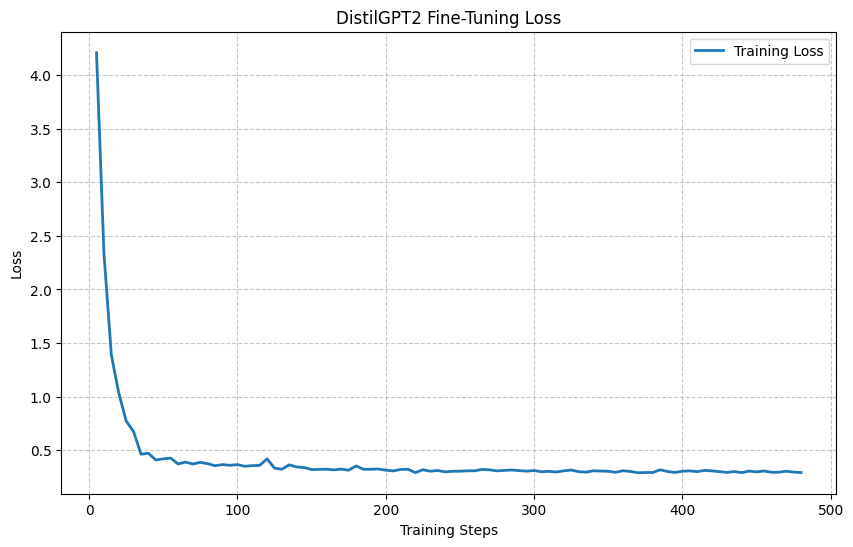

In [ ]:
# Extract loss and step data
train_logs = trainer.state.log_history
loss_history = [log["loss"] for log in train_logs if "loss" in log]
step_history = [log["step"] for log in train_logs if "loss" in log]

# Plot the loss curve
plt.figure(figsize=(10, 6))
plt.plot(step_history, loss_history, label="Training Loss", color="#1f77b4", linewidth=2)
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("DistilGPT2 Fine-Tuning Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

---

Generating some examples. For prompts, I decided to use each : as a stopping points, increasing the amount of words I was sending in to be generated. Based on previous experiments, I thought that it could showcase if the model is robust or not. The simple prompt gave pretty consistent and good results, with some missing words or periods at the end of a sentence. The medium prompt gave a consistent response, but we started to see the weirdness crepping up, where the model repeats itself (SYMPT appearing at the end of the sentence.) Lastly, the long prompt was still good, but the repeatition became worse. This model has the repeatition tendency.

---

In [ ]:
# Load our newly fine-tuned model into a pipeline
generator = pipeline(
    'text-generation',
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

prompts = [
    "SUBSYSTEM:",
    "SUBSYSTEM: motor | LOAD:",
    "SUBSYSTEM: pump | LOAD: low | SYMPTOMS:"
]

print("--- Fine-Tuned Model Predictions ---")
for prompt in prompts:
    print(f"\nPrompt: '{prompt}'")
    # Using max_new_tokens instead of max_length prevents warnings about sequence length conflicts
    outputs = generator(prompt, max_new_tokens=20, num_return_sequences=5, pad_token_id=tokenizer.eos_token_id)

    for i, out in enumerate(outputs):
        # We split by the EOS token to clean up the output, preventing the model from rambling
        text = out['generated_text'].split(tokenizer.eos_token)[0].strip()
        print(f"  {i+1}: {text}")

Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'pad_token_id', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- Fine-Tuned Model Predictions ---

Prompt: 'SUBSYSTEM:'
  1: SUBSYSTEM: motor | LOAD: nominal | SYMPTOMS: reduced output efficiency and increased vibration.
  2: SUBSYSTEM: pump | LOAD: nominal | SYMPTOMS: delayed response during startup. SYMP
  3: SUBSYSTEM: fan | LOAD: nominal | SYMPTOMS: audible rattling during operation and elevated
  4: SUBSYSTEM: pump | LOAD: high | SYMPTOMS: elevated temperature and increased vibration.
  5: SUBSYSTEM: generator | LOAD: nominal | SYMPTOMS: reduced output efficiency and fluctuating current

Prompt: 'SUBSYSTEM: motor | LOAD:'


Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  1: SUBSYSTEM: motor | LOAD: high | SYMPTOMS: elevated temperature and unstable rotational speed. SYMPTOM
  2: SUBSYSTEM: motor | LOAD: low | SYMPTOMS: reduced output efficiency. SYMPTOMS: increased vibration
  3: SUBSYSTEM: motor | LOAD: low | SYMPTOMS: intermittent noise and elevated temperature.
  4: SUBSYSTEM: motor | LOAD: high | SYMPTOMS: increased vibration and unstable rotational speed.
  5: SUBSYSTEM: motor | LOAD: low | SYMPTOMS: delayed response during startup. SYMPTOMS: audible

Prompt: 'SUBSYSTEM: pump | LOAD: low | SYMPTOMS:'
  1: SUBSYSTEM: pump | LOAD: low | SYMPTOMS: audible rattling during operation. System: fluctuating current draw and audible rattling during operation. SY
  2: SUBSYSTEM: pump | LOAD: low | SYMPTOMS: unstable rotational speed and increased vibration. Low output efficiency.
  3: SUBSYSTEM: pump | LOAD: low | SYMPTOMS: increased vibration and elevated temperature.
  4: SUBSYSTEM: pump | LOAD: low | SYMPTOMS: increased vibration and elevated temperatur

---

Saving the model to my drive.

---

In [ ]:
save_directory = "./fine_tuned_defect_distilgpt2"
trainer.save_model(save_directory)
tokenizer.save_pretrained(save_directory)
print(f"\nModel and tokenizer successfully saved to '{save_directory}'")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model and tokenizer successfully saved to './fine_tuned_defect_distilgpt2'


---

Load the non-defect data. (file: non_defect_hard_negative_dataset_20000.txt)

The file uses a pattern of SUBSYSTEM: <subsystem> | LOAD: <load> | SYMPTOMS: <symptom>. Using this pattern to extract all unique subsystems and loads and compare the resulting lists.

I plotted the load side-by-side with a bar plot for comparison.

I find all non unique combinations of subsystem, load, symptom and put them in another df so I can check. Remove from the original df.

Print before and after to see how much I removed from the df.

Class balance refers to the ratio of examples between your two categories. When a dataset is highly imbalanced, like having thousands of normal machine logs but only a few hundred defect logs, the model tends to take the easy way out during training which is to completely ignore the rare defect cases because getting them wrong barely hurts its overall score. To fix this and force the model to learn the actual differences, you have to penalize it heavily for missing the minority class or use techniques to artificially balance the scales so both classes have an equal voice during training.

---

--- Data Assessment ---
Non-Defect Subsystems: {'brakes', 'motor', 'generator', 'fan', 'pump', 'compressor'}
Defect Subsystems:     {'brakes', 'motor', 'generator', 'fan', 'pump', 'compressor'}
Do they cover the same subsystems? Yes

Non-Defect Loads: {'low', 'nominal', 'high'}
Defect Loads:     {'nominal', 'low', 'high'}
Do they cover the same loads? Yes



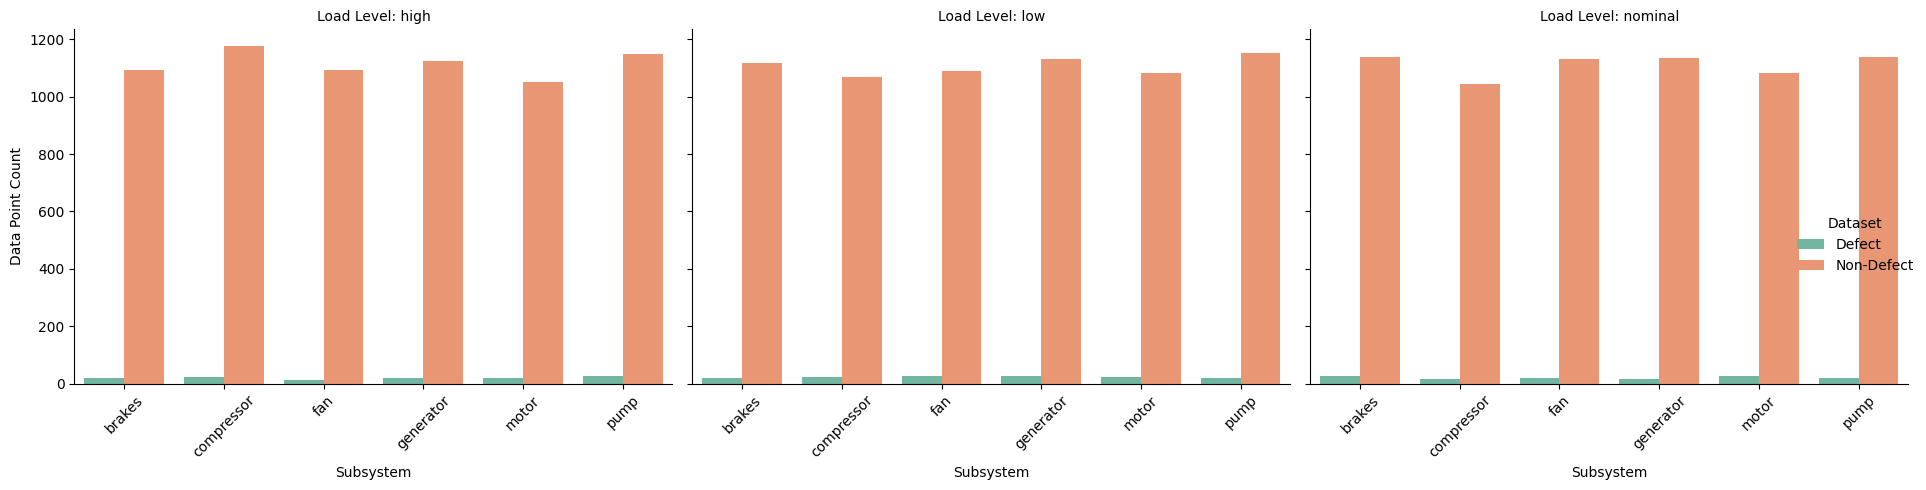

--- Deduplication ---
Before - Non-Defect Data Points: 20000
Before - Defect Data Points:     379

Saved duplicated rows to 'duplicates_non_defect.csv' and 'duplicates_defect.csv' for review.

--- Final Dataset Stats ---
After - Non-Defect Data Points: 20000
After - Defect Data Points:     304
Total Datapoints (Combined):    20304
Percentage of Defect Data:      1.50%
1: SUBSYSTEM: brakes | LOAD: high | SYMPTOMS: acoustic change briefly elevated during startup, and stabilizing without intervention over the monitoring interval.
2: SUBSYSTEM: brakes | LOAD: high | SYMPTOMS: acoustic change briefly elevated during startup, but remaining within specification during the observation window.
3: SUBSYSTEM: brakes | LOAD: high | SYMPTOMS: acoustic change briefly elevated during startup, but remaining within specification in recent operating cycles.
4: SUBSYSTEM: brakes | LOAD: high | SYMPTOMS: acoustic change briefly elevated during startup, while maintaining acceptable operating limits across 

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Data
# Non-defect data (Reading line by line into a DataFrame)
with open("non_defect_hard_negative_dataset_20000.txt", "r", encoding="utf-8") as f:
    non_defect_lines = [line.strip() for line in f if line.strip()]
df_non_defect = pd.DataFrame({"Text": non_defect_lines})

# Defect data (From your previous data cleaning step)
df_defect = pd.read_csv("filtered_defects.csv")

# 2. Extract Subsystem, Load, and Symptom using Regex
def parse_text(text):
    # Matches your exact structure
    match = re.search(r"SUBSYSTEM:\s*(.*?)\s*\|\s*LOAD:\s*(.*?)\s*\|\s*SYMPTOMS:\s*(.*)", text)
    if match:
        return match.group(1), match.group(2), match.group(3)
    return None, None, None

# Apply the parsing function and create new columns
df_non_defect[['Subsystem', 'Load', 'Symptom']] = df_non_defect['Text'].apply(lambda x: pd.Series(parse_text(x)))
df_defect[['Subsystem', 'Load', 'Symptom']] = df_defect['Defect_Text'].apply(lambda x: pd.Series(parse_text(x)))

# 3. Assess if they cover the same subsystems and loads
nd_subsystems = set(df_non_defect['Subsystem'].dropna().unique())
d_subsystems = set(df_defect['Subsystem'].dropna().unique())

nd_loads = set(df_non_defect['Load'].dropna().unique())
d_loads = set(df_defect['Load'].dropna().unique())

print("--- Data Assessment ---")
print(f"Non-Defect Subsystems: {nd_subsystems}")
print(f"Defect Subsystems:     {d_subsystems}")
print(f"Do they cover the same subsystems? {'Yes' if nd_subsystems == d_subsystems else 'No'}\n")

print(f"Non-Defect Loads: {nd_loads}")
print(f"Defect Loads:     {d_loads}")
print(f"Do they cover the same loads? {'Yes' if nd_loads == d_loads else 'No'}\n")

# 4. Plot the variability of loads across subsystems (side-by-side bar plot for each load)
# Tag the datasets before combining
df_non_defect['Dataset'] = 'Non-Defect'
df_defect['Dataset'] = 'Defect'
combined_df = pd.concat([df_non_defect, df_defect], ignore_index=True)

# Group by to get the counts for plotting
plot_data = combined_df.groupby(['Dataset', 'Subsystem', 'Load']).size().reset_index(name='Count')

# Create a multi-panel plot: one column per 'Load', plotting Subsystem counts by Dataset
g = sns.catplot(
    data=plot_data, kind="bar",
    x="Subsystem", y="Count", hue="Dataset", col="Load",
    palette="Set2", height=5, aspect=1.2
)
g.set_axis_labels("Subsystem", "Data Point Count")
g.set_titles("Load Level: {col_name}")
g.set_xticklabels(rotation=45)
plt.tight_layout()
plt.savefig("load_variability_plot.png")
plt.show()

# 5. Remove duplicates and save non-unique combinations
print("--- Deduplication ---")
print(f"Before - Non-Defect Data Points: {len(df_non_defect)}")
print(f"Before - Defect Data Points:     {len(df_defect)}\n")

# Identify duplicates (keep=False marks ALL duplicates as True so you can review them)
duplicates_non_defect = df_non_defect[df_non_defect.duplicated(subset=['Subsystem', 'Load', 'Symptom'], keep=False)]
duplicates_defect = df_defect[df_defect.duplicated(subset=['Subsystem', 'Load', 'Symptom'], keep=False)]

# Save to distinct DataFrames / CSVs so you can check them
duplicates_non_defect.to_csv("duplicates_non_defect.csv", index=False)
duplicates_defect.to_csv("duplicates_defect.csv", index=False)
print("Saved duplicated rows to 'duplicates_non_defect.csv' and 'duplicates_defect.csv' for review.\n")

# Remove duplicates from the original DataFrames (keeping the first occurrence)
df_non_defect_clean = df_non_defect.drop_duplicates(subset=['Subsystem', 'Load', 'Symptom'], keep='first')
df_defect_clean = df_defect.drop_duplicates(subset=['Subsystem', 'Load', 'Symptom'], keep='first')

# 6. Calculate Datapoints Left and Percentage
len_nd_clean = len(df_non_defect_clean)
len_d_clean = len(df_defect_clean)
total_data = len_nd_clean + len_d_clean

print("--- Final Dataset Stats ---")
print(f"After - Non-Defect Data Points: {len_nd_clean}")
print(f"After - Defect Data Points:     {len_d_clean}")
print(f"Total Datapoints (Combined):    {total_data}")

if total_data > 0:
    defect_percent = (len_d_clean / total_data) * 100
    print(f"Percentage of Defect Data:      {defect_percent:.2f}%")

# Get  the head of the non-defect logs
for idx, text in enumerate(df_non_defect_clean['Text'].head(5)):
    print(f"{idx + 1}: {text}")

---

We did not do a good job with the classifier. Maybe my stratification strategy was not perfect and I had the exact issue I described, where classifying basically everything as non-defect was considered good enough.

---

Total merged records: 20304
Train size: 14212 | Val size: 4061 | Test size: 2031


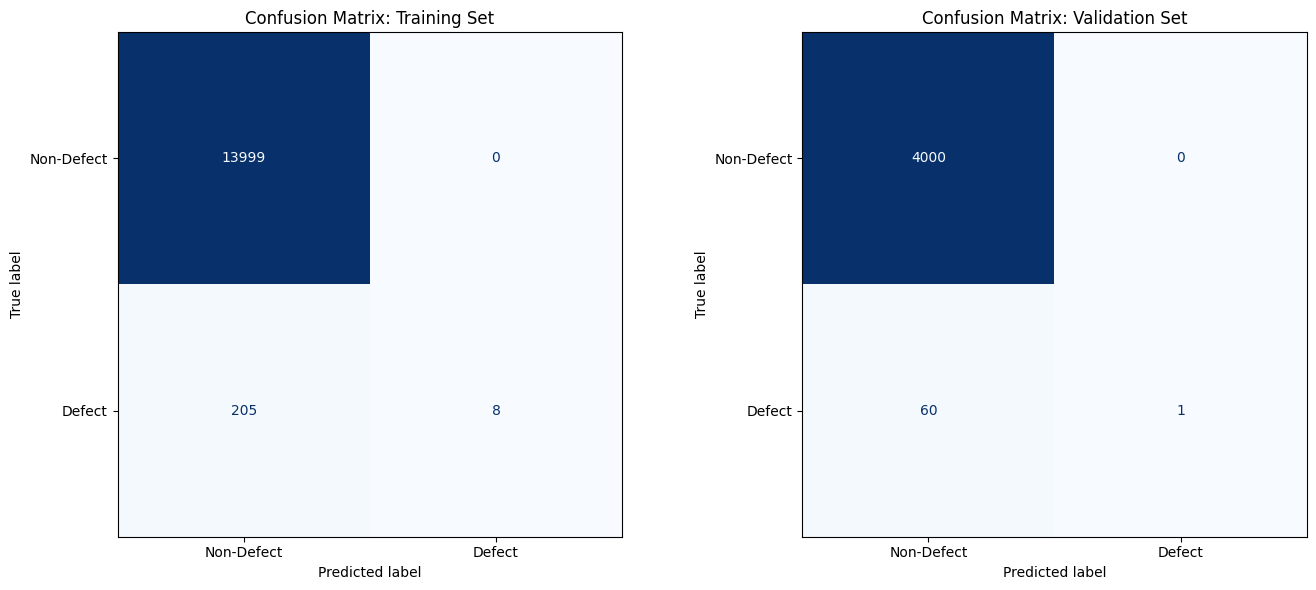

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Add binary labels and merge (assuming df_defect_clean and df_non_defect_clean from earlier)
# Standardizing the column name containing the text
df_defect_clean = df_defect_clean.rename(columns={'Defect_Text': 'Text'})
df_defect_clean['Label'] = 1      # 1 for Defect

df_non_defect_clean = df_non_defect_clean.rename(columns={'Text': 'Text'})
df_non_defect_clean['Label'] = 0  # 0 for Non-Defect

# Merge into one DataFrame
df_merged = pd.concat([df_defect_clean[['Text', 'Label']], df_non_defect_clean[['Text', 'Label']]], ignore_index=True)

print(f"Total merged records: {len(df_merged)}")

# 2. Split the data (70% Train, 20% Val, 10% Test) using Stratification
# First, split off the training set (70%), leaving 30% for Val/Test
X_train, X_temp, y_train, y_temp = train_test_split(
    df_merged['Text'],
    df_merged['Label'],
    test_size=0.30,
    stratify=df_merged['Label'], # Mandates the splits maintain the class ratio
    random_state=42
)

# Second, split the remaining 30% into Validation (20% of total) and Test (10% of total)
# 10 is 1/3 of 30, so test_size = 0.3333
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=(1/3),
    stratify=y_temp,
    random_state=42
)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")

# 3. Fit and Transform using TfidfVectorizer
vectorizer = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.95
)

# Fit ONLY on the training data to prevent data leakage, then transform all sets
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

# 4. Fit the Logistic Regression Model
clf = LogisticRegression(
    max_iter=100,
    solver="lbfgs",
    C=0.1,
    random_state=42
)

# Train the model
clf.fit(X_train_vec, y_train)

# 5. Evaluate using a Confusion Matrix for Train and Validation sets
y_train_pred = clf.predict(X_train_vec)
y_val_pred = clf.predict(X_val_vec)

# Create a side-by-side plot for the confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Train Confusion Matrix
cm_train = confusion_matrix(y_train, y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['Non-Defect', 'Defect'])
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix: Training Set')

# Validation Confusion Matrix
cm_val = confusion_matrix(y_val, y_val_pred)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=['Non-Defect', 'Defect'])
disp_val.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix: Validation Set')

plt.tight_layout()
plt.show()

---

The problem with realism that I described before still holds, where some words at the end of the sentence are trucated or there are more than one sentences separeted by periods or there is a repetition of SUBSYSTEMS. However, the confusion matrix on th evalidation set shows that we are improving the missclassification (less cases of missclassification)

---

In [ ]:
import pandas as pd

# 1. Generate 100 synthetic defect logs
print("Generating 100 synthetic defect logs. This may take a moment...")
synthetic_texts = []
prompt = "SUBSYSTEM:"

# We generate in batches of 10 to manage GPU memory efficiently
for _ in range(10):
    outputs = generator(
        prompt,
        max_new_tokens=20,
        num_return_sequences=10,
        pad_token_id=tokenizer.eos_token_id
    )
    for out in outputs:
        # Split by the EOS token to remove any trailing noise
        clean_text = out['generated_text'].split(tokenizer.eos_token)[0].strip()
        synthetic_texts.append(clean_text)

df_synthetic = pd.DataFrame({'Text': synthetic_texts})
df_synthetic['Label'] = 1  # Explicitly label these new examples as defects

# 2. Inspect the synthetic defect logs
print("Inspection of the first 5 synthetic defect logs:")
for idx, text in enumerate(df_synthetic['Text'].head(5)):
    print(f"{idx + 1}: {text}")

# 3. Create a deep copy of the original training data
# We combine X_train and y_train back into a single DataFrame for the merge
X_train_copy = X_train.copy(deep=True)
y_train_copy = y_train.copy(deep=True)
df_train_original = pd.DataFrame({'Text': X_train_copy, 'Label': y_train_copy})

# 4. Merge the synthetic logs to create the augmented training data
df_train_augmented = pd.concat([df_train_original, df_synthetic], ignore_index=True)

# Separate the augmented data back into X and y for scikit-learn
X_train_aug = df_train_augmented['Text']
y_train_aug = df_train_augmented['Label']

print(f"\nOriginal training data size: {len(df_train_original)}")
print(f"Augmented training data size: {len(df_train_augmented)}")

Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generating 100 synthetic defect logs. This may take a moment...


Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

Inspection of the first 5 synthetic defect logs:
1: SUBSYSTEM: fan | LOAD: high | SYMPTOMS: thermal spikes under sustained load and audible
2: SUBSYSTEM: fan | LOAD: low | SYMPTOMS: fluctuating current draw. The high
3: SUBSYSTEM: pump | LOAD: nominal | SYMPTOMS: thermal spikes under sustained load. The
4: SUBSYSTEM: pump | LOAD: high | SYMPTOMS: audible rattling during operation and intermittent
5: SUBSYSTEM: motor | LOAD: low | SYMPTOMS: audible rattling during operation. Possible

Original training data size: 14212
Augmented training data size: 14312


---

Here we see that roblem where defect augmentated data is all being classified as defect.

---

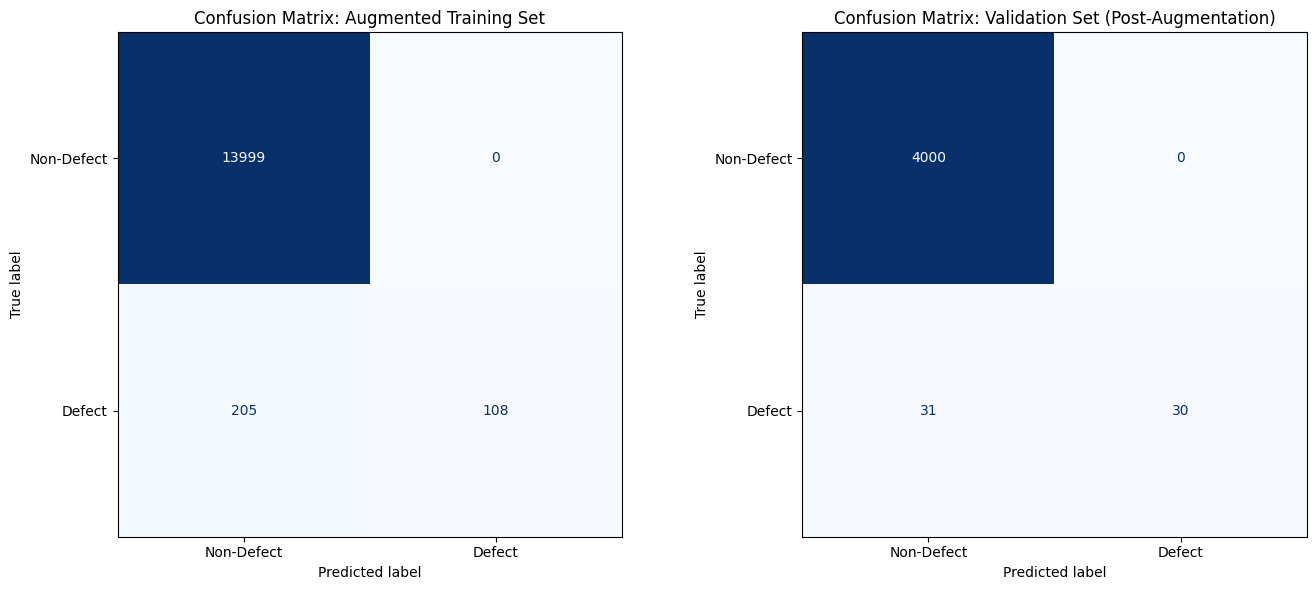

In [ ]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Re-initialize and re-fit the TF-IDF Vectorizer
vectorizer_aug = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.95
)

# Fit and transform on the AUGMENTED training data
X_train_aug_vec = vectorizer_aug.fit_transform(X_train_aug)

# Transform the original validation and testing data
# (Important: We NEVER fit on validation/test data to prevent data leakage)
X_val_vec = vectorizer_aug.transform(X_val)
X_test_vec = vectorizer_aug.transform(X_test)

# 2. Re-initialize the Logistic Regression Classifier
clf_aug = LogisticRegression(
    max_iter=100,
    solver="lbfgs",
    C=0.1,
    random_state=42
)

# 3. Fit the classifier to the augmented training data
clf_aug.fit(X_train_aug_vec, y_train_aug)

# 4. Predict on the augmented training set and original validation set
y_train_aug_pred = clf_aug.predict(X_train_aug_vec)
y_val_pred_aug = clf_aug.predict(X_val_vec)

# 5. Evaluate using Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Augmented Train Confusion Matrix
cm_train_aug = confusion_matrix(y_train_aug, y_train_aug_pred)
disp_train_aug = ConfusionMatrixDisplay(confusion_matrix=cm_train_aug, display_labels=['Non-Defect', 'Defect'])
disp_train_aug.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix: Augmented Training Set')

# Validation Confusion Matrix (Original Val Data)
cm_val_aug = confusion_matrix(y_val, y_val_pred_aug)
disp_val_aug = ConfusionMatrixDisplay(confusion_matrix=cm_val_aug, display_labels=['Non-Defect', 'Defect'])
disp_val_aug.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix: Validation Set (Post-Augmentation)')

plt.tight_layout()
plt.show()

---

Interestingly, we are improving the defect detection with data augmentation (we dropped to 77 from 205 missclassifications on the training set and down to only 5 missclassification on the validation set), where less defect are being missclassified as non-defects, which tell me that even though my augmented sets are not super real, it is helping with the class imbalance problem. Just 100 augmented cases did not help as much as 300 augmented examples (31 missclassified vs only 5 on the validaiton set).

---

Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generating 300 synthetic defect logs. This will take a few minutes...


Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma


First 5 of the 300 new synthetic logs:
1: SUBSYSTEM: brakes | LOAD: high | SYMPTOMS: increased vibration.
2: SUBSYSTEM: brakes | LOAD: nominal | SYMPTOMS: increased vibration. SYMPTOM
3: SUBSYSTEM: brakes | LOAD: high | SYMPTOMS: increased vibration. Biasomatic ratt
4: SUBSYSTEM: brakes | LOAD: low | SYMPTOMS: unstable rotational speed and audible ratt
5: SUBSYSTEM: fan | LOAD: nominal | SYMPTOMS: delayed response during startup and delayed response

Original training data size: 14212
New augmented training data size: 14512


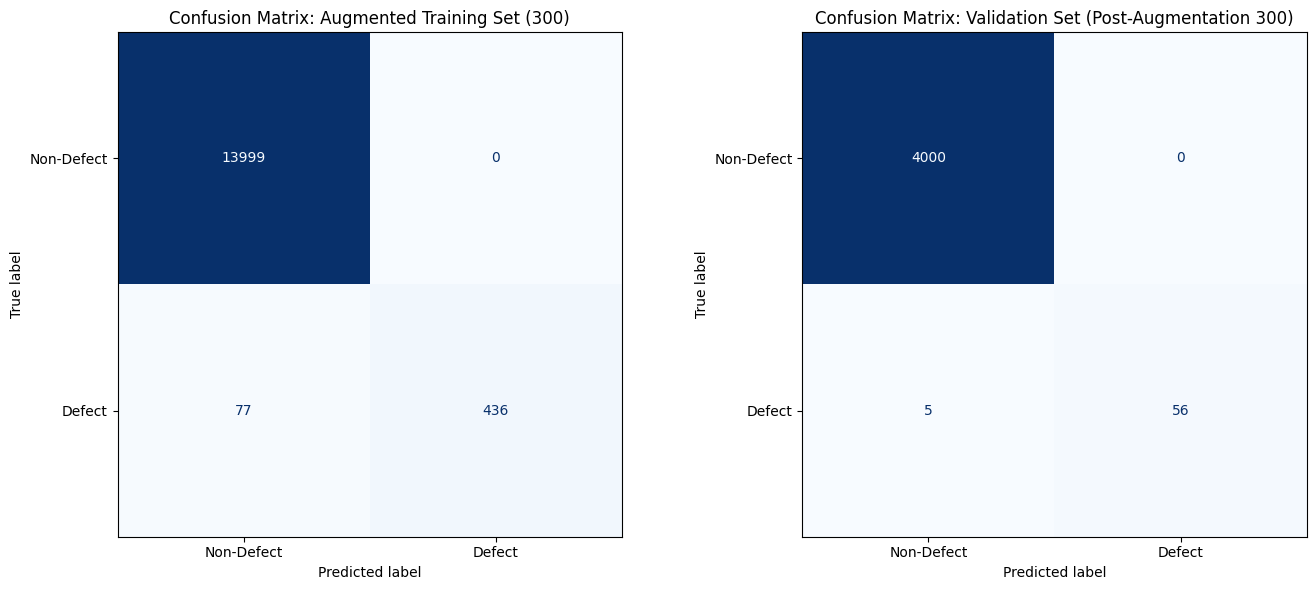

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ==========================================
# 1. Generative Data Augmentation (300 logs)
# ==========================================
print("Generating 300 synthetic defect logs. This will take a few minutes...")
synthetic_texts_300 = []
prompt = "SUBSYSTEM:"

# Generating in 30 batches of 10 to manage Colab GPU memory
for _ in range(30):
    outputs = generator(
        prompt,
        max_new_tokens=20,
        num_return_sequences=10,
        pad_token_id=tokenizer.eos_token_id
    )
    for out in outputs:
        # Split by the EOS token to clean up the text
        clean_text = out['generated_text'].split(tokenizer.eos_token)[0].strip()
        synthetic_texts_300.append(clean_text)

# Create DataFrame for the new synthetic data
df_synthetic_300 = pd.DataFrame({'Text': synthetic_texts_300})
df_synthetic_300['Label'] = 1  # Label as defects

print("\nFirst 5 of the 300 new synthetic logs:")
for idx, text in enumerate(df_synthetic_300['Text'].head(5)):
    print(f"{idx + 1}: {text}")

# ==========================================
# 2. Merge with Original Training Data
# ==========================================
# Re-create the original training dataframe just to be safe
df_train_original = pd.DataFrame({'Text': X_train.copy(deep=True), 'Label': y_train.copy(deep=True)})

# Merge the 300 new synthetic logs
df_train_aug_300 = pd.concat([df_train_original, df_synthetic_300], ignore_index=True)

# Separate back into X and y
X_train_aug_300 = df_train_aug_300['Text']
y_train_aug_300 = df_train_aug_300['Label']

print(f"\nOriginal training data size: {len(df_train_original)}")
print(f"New augmented training data size: {len(df_train_aug_300)}")


# ==========================================
# 3. Evaluate Synthetic Data via Classifier
# ==========================================

# Re-initialize and fit the TF-IDF Vectorizer
vectorizer_aug_300 = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.95
)

# Fit and transform on the NEW augmented training data
X_train_aug_300_vec = vectorizer_aug_300.fit_transform(X_train_aug_300)

# Transform the original validation and testing data
X_val_vec_300 = vectorizer_aug_300.transform(X_val)
X_test_vec_300 = vectorizer_aug_300.transform(X_test)

# Re-initialize the Logistic Regression Classifier
clf_aug_300 = LogisticRegression(
    max_iter=100,
    solver="lbfgs",
    C=0.1,
    random_state=42
)

# Fit the classifier to the new augmented training data
clf_aug_300.fit(X_train_aug_300_vec, y_train_aug_300)

# Predict on the new augmented training set and original validation set
y_train_aug_300_pred = clf_aug_300.predict(X_train_aug_300_vec)
y_val_pred_aug_300 = clf_aug_300.predict(X_val_vec_300)

# Evaluate using Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Augmented Train Confusion Matrix
cm_train_aug_300 = confusion_matrix(y_train_aug_300, y_train_aug_300_pred)
disp_train_aug_300 = ConfusionMatrixDisplay(confusion_matrix=cm_train_aug_300, display_labels=['Non-Defect', 'Defect'])
disp_train_aug_300.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix: Augmented Training Set (300)')

# Validation Confusion Matrix (Original Val Data)
cm_val_aug_300 = confusion_matrix(y_val, y_val_pred_aug_300)
disp_val_aug_300 = ConfusionMatrixDisplay(confusion_matrix=cm_val_aug_300, display_labels=['Non-Defect', 'Defect'])
disp_val_aug_300.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix: Validation Set (Post-Augmentation 300)')

plt.tight_layout()
plt.show()

---

Out of curiosity, I test with a different prompt. This time, I noticed that the "best" generated output was the medium lenght one, so I tried that instead. There is a bias, since I have to provide a SUBSYSTEM. Interestingly, I noticed that the confusion matrix did "worse" (more defects were being classified as non-defects). This indicates that I am on the right track. Since this generation is better when I inspect it, that classifier struggles. It reinforces that "because my augmentation is bad" the classifier is just focusing on the bad tokens instead of actual defects vs non-defects. The confusion matrix show a little worse than the previous one. This medium prompt did worse that the short one on the confusion matrix

---

Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generating 300 synthetic defect logs. This will take a few minutes...


Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma


First 5 of the 300 new synthetic logs:
1: SUBSYSTEM: motor | LOAD: low | SYMPTOMS: elevated temperature. SYMPTOMS: unstable rotational
2: SUBSYSTEM: motor | LOAD: low | SYMPTOMS: unstable rotational speed. System interruptions during startup and delayed
3: SUBSYSTEM: motor | LOAD: nominal | SYMPTOMS: increased vibration and reduced output efficiency. SYMPTOMS
4: SUBSYSTEM: motor | LOAD: nominal | SYMPTOMS: elevated temperature.
5: SUBSYSTEM: motor | LOAD: nominal | SYMPTOMS: intermittent noise.

Original training data size: 14212
New augmented training data size: 14512


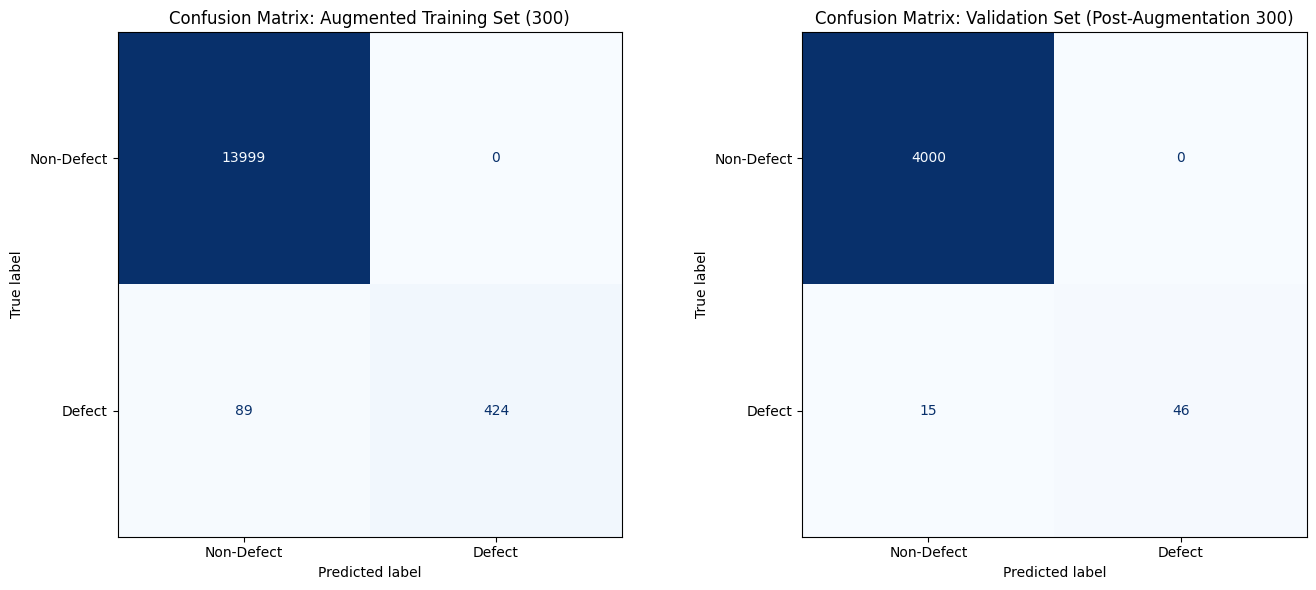

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ==========================================
# 1. Generative Data Augmentation (300 logs)
# ==========================================
print("Generating 300 synthetic defect logs. This will take a few minutes...")
synthetic_texts_300 = []
prompt = "SUBSYSTEM: motor | LOAD:"

# Generating in 30 batches of 10 to manage Colab GPU memory
for _ in range(30):
    outputs = generator(
        prompt,
        max_new_tokens=20,
        num_return_sequences=10,
        pad_token_id=tokenizer.eos_token_id
    )
    for out in outputs:
        # Split by the EOS token to clean up the text
        clean_text = out['generated_text'].split(tokenizer.eos_token)[0].strip()
        synthetic_texts_300.append(clean_text)

# Create DataFrame for the new synthetic data
df_synthetic_300 = pd.DataFrame({'Text': synthetic_texts_300})
df_synthetic_300['Label'] = 1  # Label as defects

print("\nFirst 5 of the 300 new synthetic logs:")
for idx, text in enumerate(df_synthetic_300['Text'].head(5)):
    print(f"{idx + 1}: {text}")

# ==========================================
# 2. Merge with Original Training Data
# ==========================================
# Re-create the original training dataframe just to be safe
df_train_original = pd.DataFrame({'Text': X_train.copy(deep=True), 'Label': y_train.copy(deep=True)})

# Merge the 300 new synthetic logs
df_train_aug_300 = pd.concat([df_train_original, df_synthetic_300], ignore_index=True)

# Separate back into X and y
X_train_aug_300 = df_train_aug_300['Text']
y_train_aug_300 = df_train_aug_300['Label']

print(f"\nOriginal training data size: {len(df_train_original)}")
print(f"New augmented training data size: {len(df_train_aug_300)}")


# ==========================================
# 3. Evaluate Synthetic Data via Classifier
# ==========================================

# Re-initialize and fit the TF-IDF Vectorizer
vectorizer_aug_300 = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.95
)

# Fit and transform on the NEW augmented training data
X_train_aug_300_vec = vectorizer_aug_300.fit_transform(X_train_aug_300)

# Transform the original validation and testing data
X_val_vec_300 = vectorizer_aug_300.transform(X_val)
X_test_vec_300 = vectorizer_aug_300.transform(X_test)

# Re-initialize the Logistic Regression Classifier
clf_aug_300 = LogisticRegression(
    max_iter=100,
    solver="lbfgs",
    C=0.1,
    random_state=42
)

# Fit the classifier to the new augmented training data
clf_aug_300.fit(X_train_aug_300_vec, y_train_aug_300)

# Predict on the new augmented training set and original validation set
y_train_aug_300_pred = clf_aug_300.predict(X_train_aug_300_vec)
y_val_pred_aug_300 = clf_aug_300.predict(X_val_vec_300)

# Evaluate using Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Augmented Train Confusion Matrix
cm_train_aug_300 = confusion_matrix(y_train_aug_300, y_train_aug_300_pred)
disp_train_aug_300 = ConfusionMatrixDisplay(confusion_matrix=cm_train_aug_300, display_labels=['Non-Defect', 'Defect'])
disp_train_aug_300.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix: Augmented Training Set (300)')

# Validation Confusion Matrix (Original Val Data)
cm_val_aug_300 = confusion_matrix(y_val, y_val_pred_aug_300)
disp_val_aug_300 = ConfusionMatrixDisplay(confusion_matrix=cm_val_aug_300, display_labels=['Non-Defect', 'Defect'])
disp_val_aug_300.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix: Validation Set (Post-Augmentation 300)')

plt.tight_layout()
plt.show()

---

# CONCLUSION

There is a big challenge when we asses the quality of synthesized text because, as we saw, generative outputs lacks an absolute ground truth. We have to rely on downstream classifier performance to provide an objectivy metric. If the generative model successfully captures the true semantic distribution of the defect class, adding its synthetic outputs to the training set should enhance the decision boundary of a classifier. This approach translates subjective text evaluation into a concrete, measurable impact on predictive accuracy.

There is a methodological flaw in the described training scheme. The transformer was fine-tuned on the entire defect dataset before the data was partitioned. Consequently, the generative model memorized patterns from the exact examples that would later serve as the validation and test sets.

When this transformer generates synthetic data to augment the classifier's training set, it inadvertently bleeds information from the holdout sets into the training phase. This is a case of data leakage, ommited by the extra step we took.

This leakage complicates or even invalidates the interpretation of the results. Any observed improvement in the augmented classifier's performance on the validation or test sets is an artifact of the model having indirect prior exposure to that exact testing data. To properly evaluate the generative augmentation, the initial dataset must be split first. The generative model must be fine-tuned strictly on the training partition, ensuring the validation and test distributions remain completely unseen and sequestered.

The overall architecture of this project represents a sophisticated approach to handling severe class imbalance. Navigating from raw text to a fine-tuned generative model, to a downstream classification pipeline requires rigorous data engineering. Generative language models for data augmentation reminds me of the Variational Autoencoder that we learn at the start of the semester where we generated new, valid examples along a specific target distribution. Both techniques solve the problem of scarce data by using math to model the underlying features of the minority class. If we refined the data partitioning strategy to strictly prevent the mentioned data leakage and swapped to a contextual embedding instead of the one we did, this pipeline would be even better and serve as an cool framework for anomaly detection.

---

---

# EXTRA THOUGHTS

I don't think my classifier is capturing the nuanced difference between the non-defect and defect (machine had a hiccup but works vs machine broken down). BEFORE augmentation, basically all defects were being classified as non-defects. After augmentation, because my augmentation was bad (sometimes there is a cut at the end of the sentence or the SUBSYSTEM part gets repeated at the end), the confusion matrix appears to improve, but I don't think it is capturing that original difference, but instead focusing on "bad" generated examples.

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/PhD/Generative_AI_for_Engineers/
! pwd
! jupyter nbconvert --to PDF "Transformers"

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipython-input-7247/2979827783.py", line 4, in <cell line: 0>
    get_ipython().run_line_magic('cd', '/content/drive/MyDrive/PhD/Generative_AI_for_Engineers/')
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 2418, in run_line_magic
    result = fn(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^
  File "<decorator-gen-85>", line 2, in cd
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/magic.py", line 187, in <lambda>
    call = lambda f, *a, **k: f(*a, **k)
                              ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/magics/osm.py", line 342, in cd
    oldcwd = o